In [1]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
import librosa
import numpy as np
import os
import pandas as pd
import random
import matplotlib.pyplot as plt
import cv2
from matplotlib import cm

import keras
from keras import layers
import tensorflow as tf

from transformers import Resampler, NoiseAdder, BandPassFilter, WaveletDenoiser, Normalizer, MelSpectrogramTransformer, SpectrogramPadder, SpectralSubtractor
from config import SAMPLING_RATE, SEED, TEST_SIZE, N_MELS, MAX_DURATION, MIN_DURATION, PADDING_MODE, N_FFT, HOP_LENGTH

In [2]:
def plot_mel_spectrogram(y, sr=SAMPLING_RATE, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS)
    S_dB = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', ax=ax);

def normalize_spec(spec):
    spec_min, spec_max = spec.min(), spec.max()
    spec = (spec - spec_min) / (spec_max - spec_min + 1e-6)
    spec = (spec * 255).astype(np.uint8)
    return spec

def spec_to_rgb(spec):
    spec = normalize_spec(spec)
    spec_color = cm.magma(spec / 255.0)[:, :, :3]  # RGB float 0–1
    return (spec_color * 255).astype(np.uint8)

def save_mel_images(X, y, split_name, dataset):
    output_dir = f'./mobile_net/mel_images/{dataset}/{split_name}'
    os.makedirs(output_dir, exist_ok=True)

    filenames = []
    for i, spec in enumerate(X):
        spec_rgb = spec_to_rgb(np.flipud(spec))
        # cv2 usa BGR → convertimos para guardar bien los colores
        cv2.imwrite(os.path.join(output_dir, f"{i}.png"), cv2.cvtColor(spec_rgb, cv2.COLOR_RGB2BGR))
        filenames.append(f"{i}.png")

    pd.DataFrame({
        'filename': filenames,
        'label': y
    }).to_csv(f'{output_dir}/labels.csv', index=False)

In [3]:
df = pd.read_csv('./dataset/audios_ciclos/metadata.csv')

In [4]:
df['label'] = np.where((df['crackles'] == 0) & (df['wheezes'] == 0), 0, 1)
df.head()

,patient,recording_index,location,mode,instrument,cycle_number,start_sec,end_sec,duration_sec,crackles,wheezes,cycle_wav_file,wav_base_file,age,sex,adult_bmi,child_weight,child_height,diagnosis,label
0,101,1b1,Al,sc,Meditron,1,0.036,0.579,0.543,0,0,101_1b1_Al_sc_Meditron_cycle1.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0
1,101,1b1,Al,sc,Meditron,2,0.579,2.450,1.871,0,0,101_1b1_Al_sc_Meditron_cycle2.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0
2,101,1b1,Al,sc,Meditron,3,2.450,3.893,1.443,0,0,101_1b1_Al_sc_Meditron_cycle3.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0
3,101,1b1,Al,sc,Meditron,4,3.893,5.793,1.900,0,0,101_1b1_Al_sc_Meditron_cycle4.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0
4,101,1b1,Al,sc,Meditron,5,5.793,7.521,1.728,0,0,101_1b1_Al_sc_Meditron_cycle5.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0


In [5]:
df = df[df['duration_sec'] < MAX_DURATION].copy()
df = df[df['duration_sec'] > MIN_DURATION].copy()

In [37]:
X = df['cycle_wav_file'].tolist()
y = df['label'].tolist()

X = [os.path.join('./dataset/audios_ciclos/', path) for path in X]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)

# Imagenes

In [38]:
noise_paths = os.listdir('./audios_propios/ruido')
noise_paths = [os.path.join('./audios_propios/ruido/', path) for path in noise_paths]

test_noise_paths = os.listdir('./audios_propios/ruido_test')
test_noise_paths = [os.path.join('./audios_propios/ruido_test/', path) for path in test_noise_paths]

In [39]:
random.seed(SEED)

resampler = Resampler()
X_train_resampled = resampler.fit_transform(X_train)
X_test_resampled = resampler.transform(X_test)

In [40]:
# white_noise_adder = NoiseAdder(noise_files=[], mode='white', snr_min=5, snr_max=10, random_state=SEED)
real_noise_adder = NoiseAdder(noise_files=noise_paths, mode='pool', snr_min=4, snr_max=7, random_state=SEED)
real_noise_adder_strong = NoiseAdder(noise_files=noise_paths, mode='pool', snr_min=1, snr_max=3, random_state=SEED)

real_noise_adder_test = NoiseAdder(noise_files=test_noise_paths, mode='pool', snr_min=5, snr_max=8, random_state=SEED)
real_noise_adder_test_strong = NoiseAdder(noise_files=test_noise_paths, mode='pool', snr_min=1, snr_max=4, random_state=SEED)

In [41]:
# indices_white_train = random.sample(range(len(X_train_resampled)), int(0.10 * len(X_train_resampled)))
indices_real_train  = random.sample(range(len(X_train_resampled)), int(0.90 * len(X_train_resampled)))
indices_real_strong_train = random.sample(range(len(X_train_resampled)), int(0.80 * len(X_train_resampled)))

indices_real_test  = random.sample(range(len(X_test_resampled)), int(0.90 * len(X_test_resampled)))
indices_real_strong_test = random.sample(range(len(X_test_resampled)), int(0.80 * len(X_test_resampled)))

In [42]:
# X_train_white = white_noise_adder.transform([X_train_resampled[i] for i in indices_white_train])
X_train_real  = real_noise_adder.transform([X_train_resampled[i] for i in indices_real_train])
X_train_real_strong = real_noise_adder_strong.transform([X_train_resampled[i] for i in indices_real_strong_train])

X_test_real  = real_noise_adder_test.transform([X_test_resampled[i] for i in indices_real_test])
X_test_real_strong = real_noise_adder_test_strong.transform([X_test_resampled[i] for i in indices_real_strong_test])

X_train_augmented = (
    X_train_resampled +
    # X_train_white +
    X_train_real +
    X_train_real_strong
)
y_train_augmented = (
    y_train +
    # [y_train[i] for i in indices_white_train] +
    [y_train[i] for i in indices_real_train] +
    [y_train[i] for i in indices_real_strong_train]
)

X_test_augmented = (
    X_test_resampled +
    X_test_real +
    X_test_real_strong
)
y_test_augmented = (
    y_test +
    [y_test[i] for i in indices_real_test] +
    [y_test[i] for i in indices_real_strong_test]
)

In [43]:
# conjuntos augmented
X_train_augmented, X_val_augmented, y_train_augmented, y_val_augmented = train_test_split(
    X_train_augmented, y_train_augmented, test_size=TEST_SIZE, random_state=SEED, stratify=y_train_augmented
)

# conjuntos originales
X_train, X_val, y_train, y_val = train_test_split(
    X_train_resampled, y_train, test_size=TEST_SIZE, random_state=SEED, stratify=y_train
)

In [44]:
print(len(X_train), len(X_val), len(X_test))

print(len(X_train_augmented), len(X_val_augmented), len(X_test_augmented))

4144 1037 1296
11189 2798 3498


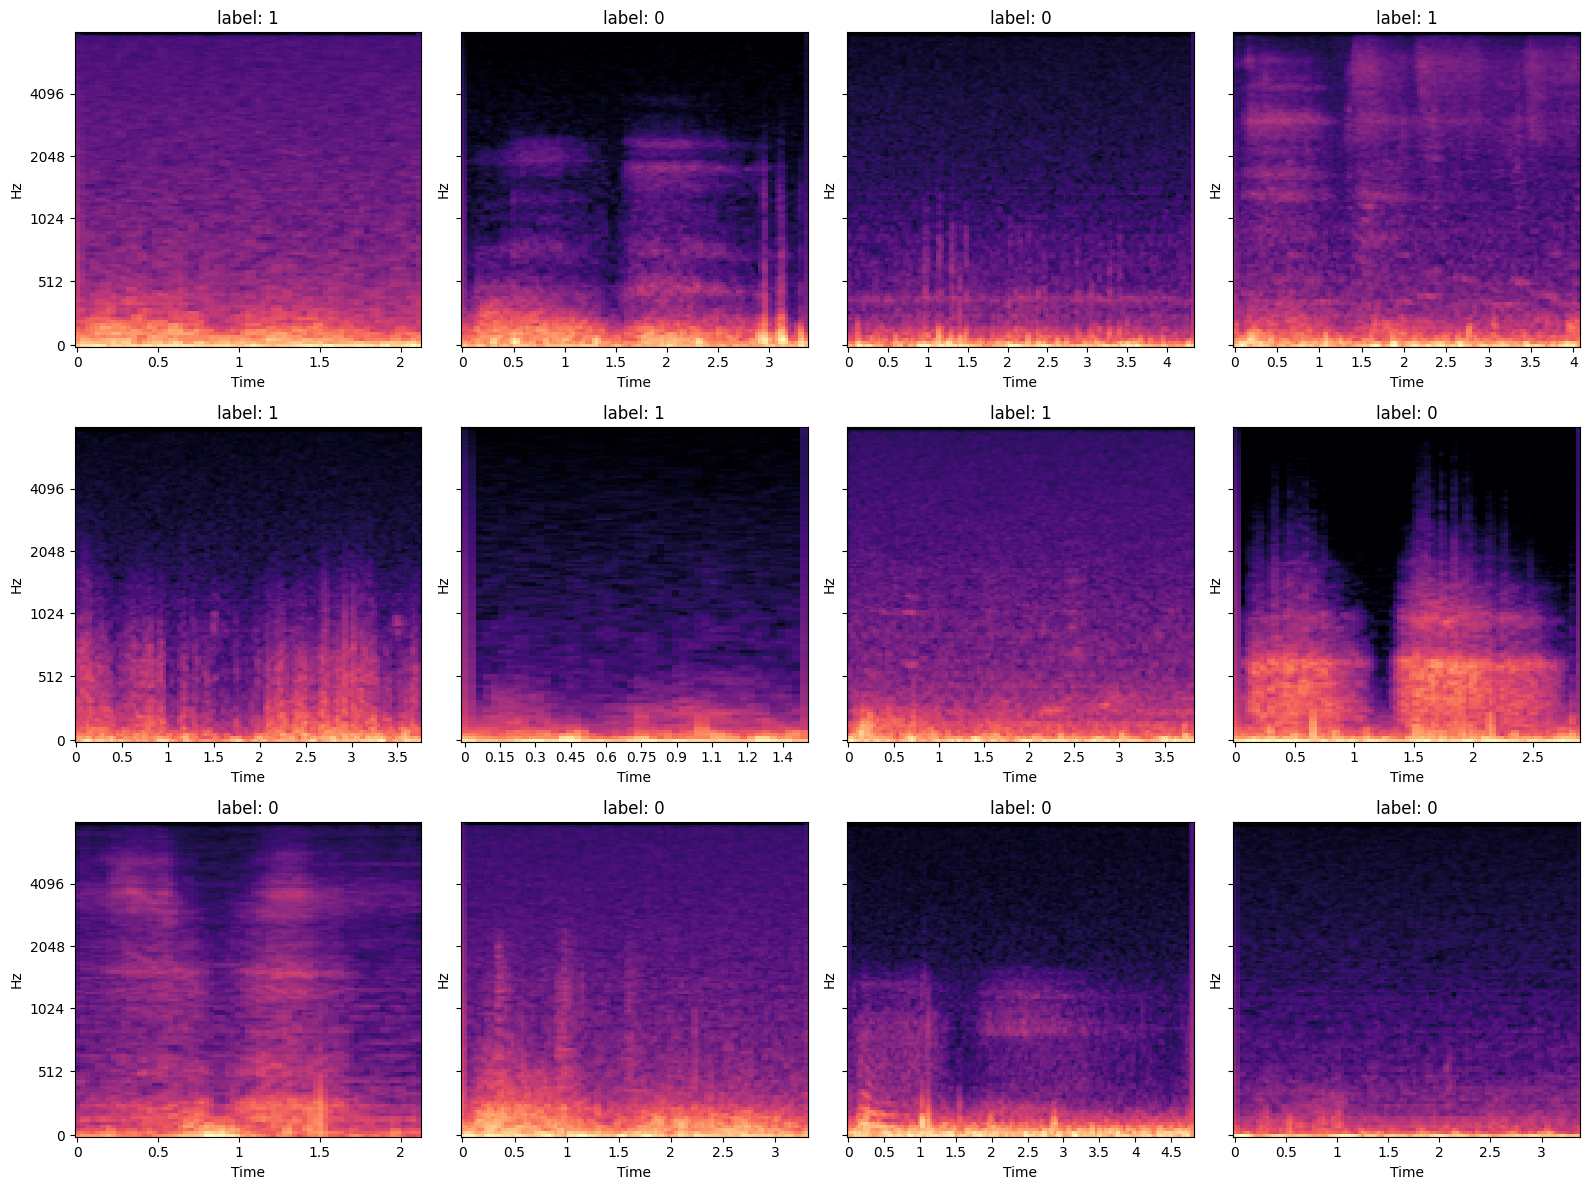

In [45]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12), sharey=True)

axes = axes.flatten()

for i, x in enumerate(X_train[-12:]):
    ax = axes[i]
    plot_mel_spectrogram(x, SAMPLING_RATE, ax=ax)
    ax.set_title(f"label: {y_train[i]}")

plt.tight_layout();

## Sin padding

In [46]:
dataset_orig = 'orig'
dataset_aug = 'aug'

In [47]:
pipeline_melspec_img = Pipeline([
    # ('bandpass', BandPassFilter()),
    # ('denoiser', SpectralSubtractor()),
    ('melspec', MelSpectrogramTransformer())
])

In [ ]:
X_train_mels = pipeline_melspec_img.fit_transform(X_train)
X_val_mels = pipeline_melspec_img.transform(X_val)
X_test_mels = pipeline_melspec_img.transform(X_test_resampled)

In [19]:
save_mel_images(X_train_mels, y_train, 'train', dataset_orig)
save_mel_images(X_val_mels, y_val, 'val', dataset_orig)
save_mel_images(X_test_mels, y_test, 'test', dataset_orig)

In [49]:
X_train_mels_aug = pipeline_melspec_img.fit_transform(X_train_augmented)
X_val_mels_aug = pipeline_melspec_img.transform(X_val_augmented)
X_test_mels_aug = pipeline_melspec_img.transform(X_test_augmented)

c:\Users\nazar\Clasificador-Respiracion\venv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [50]:
save_mel_images(X_train_mels_aug, y_train_augmented, 'train', dataset_aug)
save_mel_images(X_val_mels_aug, y_val_augmented, 'val', dataset_aug)
save_mel_images(X_test_mels_aug, y_test_augmented, 'test', dataset_aug)

## Con Padding

In [ ]:
dataset_orig = 'orig_no_bp_pad'
dataset_aug = 'aug_no_bp_pad'

In [ ]:
pipeline_melspec_pad_img = Pipeline([
    # ('bandpass', BandPassFilter()),
    ('melspec', MelSpectrogramTransformer()),
    ('pad', SpectrogramPadder())
])

In [ ]:
X_train_mels_padded = pipeline_melspec_pad_img.fit_transform(X_train)
X_val_mels_padded = pipeline_melspec_pad_img.transform(X_val)
X_test_mels_padded = pipeline_melspec_pad_img.transform(X_test_resampled)

c:\Users\nazar\Clasificador-Respiracion\venv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [ ]:
save_mel_images(X_train_mels_padded, y_train, 'train', dataset_orig)
save_mel_images(X_val_mels_padded, y_val, 'val', dataset_orig)
save_mel_images(X_test_mels_padded, y_test, 'test', dataset_orig)

In [ ]:
max_length = 0
for x in X_train_mels_aug:
    if x.shape[1] > max_length:
        max_length = x.shape[1]
print("Max resolucion temporal:", max_length)

Max resolucion temporal: 373


Las imagenes con padding tendrian resolucion 128x373

In [ ]:
X_train_mels_aug_padded = pipeline_melspec_pad_img.fit_transform(X_train_augmented)
X_val_mels_aug_padded = pipeline_melspec_pad_img.transform(X_val_augmented)
X_test_mels_aug_padded = pipeline_melspec_pad_img.transform(X_test_augmented)

c:\Users\nazar\Clasificador-Respiracion\venv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [ ]:
save_mel_images(X_train_mels_aug_padded, y_train_augmented, 'train', dataset_aug)
save_mel_images(X_val_mels_aug_padded, y_val_augmented, 'val', dataset_aug)
save_mel_images(X_test_mels_aug_padded, y_test_augmented, 'test', dataset_aug)

# Melspec con keras

In [32]:
X_train = np.array(X_train_padded)
X_val = np.array(X_val_padded)
X_test = np.array(X_test_padded)

In [33]:
X_train.shape

(11189, 96000)

In [ ]:
inputs = keras.Input(shape=(MAX_LENGTH_SAMPLES,))

In [66]:
melspec_layer = layers.MelSpectrogram(
    fft_length=2048, # N_FFT
    sequence_stride=128, # HOP_LENGTH
    sampling_rate=SAMPLING_RATE,
    num_mel_bins=256,
    power_to_db=True,
    min_freq=0,
    max_freq=4000
)

In [67]:
X_batch = np.array(X_train[:10], dtype=np.float32)

mel_outputs = melspec_layer(X_batch)

In [68]:
mel_outputs.shape

TensorShape([10, 256, 751])

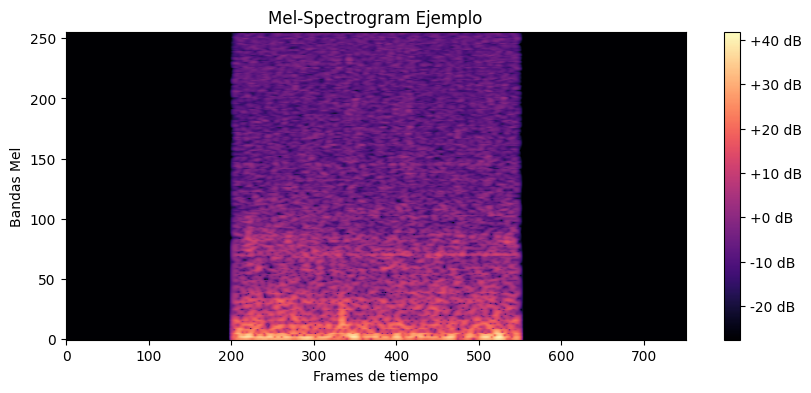

In [80]:
mel_example = mel_outputs[6].numpy()

plt.figure(figsize=(10, 4))
plt.imshow(mel_example, aspect='auto', origin='lower', cmap='magma')
plt.title("Mel-Spectrogram Ejemplo")
plt.xlabel("Frames de tiempo")
plt.ylabel("Bandas Mel")
plt.colorbar(format='%+2.0f dB')
plt.show()

In [81]:
min_val = -27.612438
max_val = 80.0

scale_layer = keras.layers.Rescaling(
    scale=2.0 / (max_val - min_val),
    offset=-(max_val + min_val) / (max_val - min_val)
)

In [83]:
mel_example_scaled = scale_layer(mel_example)

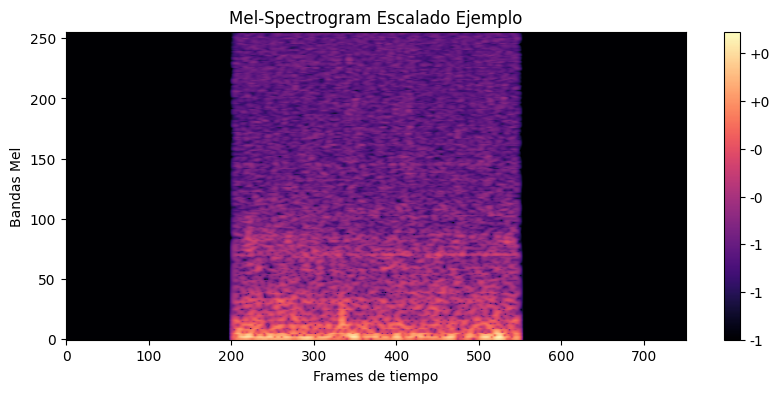

In [84]:
plt.figure(figsize=(10, 4))
plt.imshow(mel_example_scaled, aspect='auto', origin='lower', cmap='magma')
plt.title("Mel-Spectrogram Escalado Ejemplo")
plt.xlabel("Frames de tiempo")
plt.ylabel("Bandas Mel")
plt.colorbar(format='%+2.0f')
plt.show()

In [85]:
mel_outputs.shape

TensorShape([10, 256, 751])

In [92]:
transpose_layer = layers.Permute((2, 1))  # ahora (batch, time, n_mels)

# agrega eje de canal
channel_layer = layers.Lambda(lambda y: tf.expand_dims(y, axis=-1))  # (batch, time, n_mels, 1)

# repite canales a 3
channels_layer = layers.Lambda(lambda y: tf.repeat(y, 3, axis=-1))  # (batch, time, n_mels, 3)

In [105]:
base_model = keras.applications.MobileNetV2(
    input_shape=(751, 256, 3), # time frames, n_mels, 3 channels
    weights='imagenet',
    include_top=False,
)

base_model.trainable = False

C:\Users\nazar\AppData\Local\Temp\ipykernel_4812\211606595.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


In [106]:
x = melspec_layer(inputs)
x = transpose_layer(x)
x = channel_layer(x)
x = channels_layer(x)
x = base_model(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.2)(x)
outputs = keras.layers.Dense(1, activation='sigmoid')(x)
model = keras.Model(inputs, outputs)

In [107]:
model.summary(show_trainable=True)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, None)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ mel_spectrogram_9           │ (None, 256, None)     │          0 │   -   │
│ (MelSpectrogram)            │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ permute (Permute)           │ (None, None, 256)     │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ lambda (Lambda)             │ (None, None, 256, 1)  │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ lambda_1 (Lambda)           │ (None, None, 256, 3)  │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ mobilenetv2_1.00_224        │ (None, None, 8, 1280) │  2,257,984 │   N   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d_3  │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_3 (Dropout)         │ (None, 1280)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_3 (Dense)             │ (None, 1)             │      1,281 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [114]:
X_train = tf.convert_to_tensor(X_train, dtype=tf.float32)
y_train = tf.convert_to_tensor(y_train, dtype=tf.float32)
X_val = tf.convert_to_tensor(X_val, dtype=tf.float32)
y_val = tf.convert_to_tensor(y_val, dtype=tf.float32)

In [116]:
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.AUC()],
)

model.fit(X_train, y_train, epochs=5, validation_data=(X_val, y_val))

Epoch 1/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 2391s 7s/step - auc_3: 0.5711 - loss: 0.6914 - val_auc_3: 0.6016 - val_loss: 0.6738
Epoch 2/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 2903s 8s/step - auc_3: 0.6073 - loss: 0.6752 - val_auc_3: 0.6201 - val_loss: 0.6683
Epoch 3/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 1666s 5s/step - auc_3: 0.6205 - loss: 0.6700 - val_auc_3: 0.6242 - val_loss: 0.6657
Epoch 4/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 1556s 4s/step - auc_3: 0.6308 - loss: 0.6653 - val_auc_3: 0.6332 - val_loss: 0.6640
Epoch 5/5
 33/350 ━━━━━━━━━━━━━━━━━━━━ 19:34 4s/step - auc_3: 0.6197 - loss: 0.6633

KeyboardInterrupt: 